In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('/home/nazanin/github/dt-inspired-neuro-fuzzy')

In [3]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.litanfis import LitAnfis, SklearnLitAnfisWrapper
from model.unfis import UNFIS, SklearnUNFISWrapper
from model.GIFT import GIFT, SklearnGIFTWrapper, MamdaniGIFT
from model.anfis import ANFIS, SklearnAnfisWrapper
from model.griffin import GRIFFIN, SklearnGRIFFINrapper
from model.giftshift import GIFTSHIFT, SklearnGIFTSHIFTWrapper
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from tests.evaluate import Evaluator


# TODO: del "giftshiftentropy"

In [4]:
# config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
random_state = 199

lr = 0.005
max_lr = 0.01
epochs = 100

alpha = 1.0
min_alpha = 0.0
noise_evaluate = True

learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       max_lr=max_lr,
                       epochs=epochs,
                       alpha=alpha,
                       min_alpha=min_alpha)

In [ ]:
# datasetdec

from tests.tabular_small import (
    Cryotheraphy, Haberman, Heart, Glass, SegmentaitionUCI, Wine, Thyroid,
    Immunotherapy, Iris, BreastCancer, PimaDiabetes, CarEvaluation, Autism,
    Digits, DNA, MFeat, Parkinson, SyntheticGaussian, PimaDiabetesCase2,
    DigitsUCI as Digits_UCI, BCW,
)
from tests.tabular_large import AdultIncome, BankMarketing, Smoke
from tests.bio_medical import Diabetes, Colon, Leukemia, SRBCT, Madelon, ORL, Isolet
from tests.image import MNIST, FashionMNIST
from tests.uci_thresholded import (
    EnergyEfficiencyHeating, EnergyEfficiencyCooling, Airfoil, Concrete,
    ConcreteMulticlass, CCPP,
)
from tests.inequality import (
    LinearThreshold, ExponentialGrowth, LogisticGrowth, DampedOscillator, PDE,
)
from torch.utils.data import DataLoader


#experiment = Madelon()  # Changed from session_id=random_state to use default balanced folds
experiment = PimaDiabetes(session_id=random_state)
train_dataset = experiment.train_dataset(device)
test_dataset = experiment.test_dataset(device)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)


learning_params['train_size'] = experiment.train_numpy()[0].shape[0]
#regression = experiment.target_type == 'regression'
regression = False

True

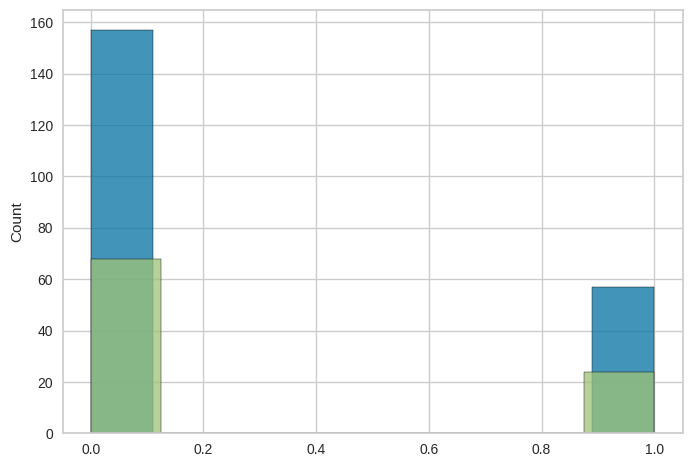

In [6]:
sns.histplot(experiment.train_numpy()[1])
sns.histplot(experiment.test_numpy()[1])

binary = len(np.unique(experiment.train_numpy()[1])) == 2
binary

In [7]:
# prepare the model - modeldec

from train.early_stop import EarlyStopping
 
model_params = {
    'type': "gift",  # anfis, unfis, gift, litanfis, gift-mamdani, griffin, giftshift, giftshiftentropy
    'in_features': experiment.train_numpy()[0].shape[1],
    'out_features': len(np.unique(experiment.train_numpy()[1])),
    'rules': 2,
    'drop_out_p': 0.3,
    'binary': binary,
}
zeta = 1.0
rank = 2
eta = 1
Xi = 1
 
entropy_coef = 0.0005
model_type = model_params.pop('type')
 
if model_type == "anfis":
    model = ANFIS(**model_params, dtype=torch.float32)
    sk_model = SklearnAnfisWrapper(model, device=device)
elif model_type == "litanfis":
    model = LitAnfis(**model_params, dtype=torch.float32)
    sk_model = SklearnLitAnfisWrapper(model, device=device)
elif model_type == "unfis":
    model = UNFIS(**model_params, dtype=torch.float32)
    sk_model = SklearnUNFISWrapper(model, device=device)
elif model_type == "gift":
    model = GIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTWrapper(model, device=device)
elif model_type == "gift-mamdani":
    model = MamdaniGIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTWrapper(model, device=device)
elif model_type == "griffin":
    model = GRIFFIN(**model_params, dtype=torch.float32, zeta=1, rank=rank, eta=eta, Xi=Xi, regression=regression)
    sk_model = SklearnGRIFFINrapper(model, device=device)
elif model_type == "giftshift":
    model = GIFTSHIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTSHIFTWrapper(model, device=device)
else:
    raise ValueError("model_type should be one of anfis, unfis, gift, litanfis, griffin, giftshift, giftshiftentropy")
 
optimizer = optim.Adam(model.parameters(), lr=lr)
 
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=max_lr,
                       steps_per_epoch=steps_per_epoch, epochs=epochs)
 
early_stopping = EarlyStopping(patience=10, delta=-0.00001)
 
# FIX Bug 3: clamp min_alpha to avoid power(0, ...) = 0 collapse.
# Also multiply decay_steps by steps_per_epoch so the half-life is
# measured in optimizer steps (matching scheduler), not just epochs.
safe_min_alpha = max(min_alpha, 1e-6)
decay_steps = steps_per_epoch * epochs / 2
alpha_decaying = np.power(safe_min_alpha / alpha, 1.0 / decay_steps)
 
cos = nn.L1Loss()
 
if binary:
    cross = nn.BCEWithLogitsLoss()
 
    def criterion(batch_X, batch_y, outputs, reconstructed, entropy_penalty=None, alpha=1.0, entropy_coef=0.0):
        main_loss = cross(outputs.squeeze(), batch_y.squeeze())
        reconstruction_loss = cos(reconstructed, batch_X) * alpha
        if entropy_penalty is not None and entropy_coef > 0:
            entropy_loss = entropy_penalty.mean() * entropy_coef
            return main_loss + reconstruction_loss + entropy_loss
        return main_loss + reconstruction_loss
 
else:
    cross = nn.CrossEntropyLoss()
 
    def criterion(batch_X, batch_y, outputs, reconstructed, entropy_penalty=None, alpha=1.0, entropy_coef=0.0):
        main_loss = cross(outputs, batch_y.long())
        reconstruction_loss = cos(reconstructed, batch_X) * alpha
        if entropy_penalty is not None and entropy_coef > 0:
            entropy_loss = entropy_penalty.mean() * entropy_coef
            return main_loss + reconstruction_loss + entropy_loss
        return main_loss + reconstruction_loss


In [8]:
# train


import random
import matplotlib.pyplot as plt
 
def set_random_state(seed=None):
    if seed is None:
        seed = np.random.randint(0, 2**32 - 1)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return seed
 
set_random_state(random_state)
 
history = []
 
train_entropy_values = []
val_entropy_values = []
epochs_list = []
 
has_entropy_reg = hasattr(model, 'entropy_coef')
if has_entropy_reg:
    print(f"Using entropy regularization with coefficient: {model.entropy_coef}")
 
# FIX Bug 5: log interpretable params for ALL model types that support it,
# not just 'gift' and 'litanfis'. Previously giftshift/giftshiftentropy were skipped.
LOGGABLE_TYPES = {'gift', 'litanfis', 'giftshift', 'giftshiftentropy'}
# del
batch_idx_check = 0
 
for epoch in range(epochs):
 
    model.train()
    train_loss = 0
    train_reconstruction_loss = 0
    train_entropy_sum = 0 if has_entropy_reg else None
 
    # FIX Bug 5: was `if model_type == 'gift' or model_type == "litanfis"`
    if model_type in LOGGABLE_TYPES:
        stats = model.get_interpretable_params()
        stats["epoch"] = epoch
        history.append(stats)
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: {stats}")
 
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
 
        outputs = model(batch_X)
 
        if len(outputs) == 3:
            outputs, reconstructed, entropy_penalty = outputs
        else:
            outputs, reconstructed = outputs
            entropy_penalty = None
 
        if has_entropy_reg and entropy_penalty is not None:
            loss = criterion(
                batch_X, batch_y, outputs, reconstructed,
                entropy_penalty, alpha, model.entropy_coef
            )
            train_entropy_sum += entropy_penalty.mean().item() * batch_X.size(0)
        else:
            try:
                loss = criterion(batch_X, batch_y, outputs, reconstructed, None, alpha, 0.0)
            except TypeError:
                loss = criterion(batch_X, batch_y, outputs, reconstructed, alpha)
 
        loss.backward()

        # del
        if epoch == 0 and batch_idx_check==0:
            batch_idx_check += 1  # just first batch is enough
            for name, p in model.named_parameters():
                if p.grad is not None:
                    print(name, p.grad.norm().item())

        optimizer.step()
 
        try:
            scheduler.step()
        except ValueError as e:
            if "Tried to step" in str(e) and "total steps" in str(e):
                pass
            else:
                raise
 
        train_loss += loss.item() * batch_X.size(0)
        train_reconstruction_loss += torch.nn.functional.l1_loss(reconstructed, batch_X).item() * batch_X.size(0)
 
    # FIX Bug 3: clamp alpha so it never drops below safe_min_alpha
    alpha = max(safe_min_alpha, alpha * alpha_decaying)
    train_loss /= len(train_loader.dataset)
    train_reconstruction_loss /= len(train_loader.dataset)
 
    if has_entropy_reg and train_entropy_sum is not None:
        train_entropy_avg = train_entropy_sum / len(train_loader.dataset)
        train_entropy_values.append(train_entropy_avg)
    else:
        train_entropy_avg = 0.0
 
    model.eval()
    val_loss = 0
    val_entropy_sum = 0
 
    with torch.no_grad():
        for data, target in test_loader:
            output_tuple = model(data)
 
            if len(output_tuple) == 3:
                output, _, entropy_penalty = output_tuple
                if has_entropy_reg:
                    val_entropy_sum += entropy_penalty.mean().item() * data.size(0)
            else:
                output, _ = output_tuple
 
            if binary:
                loss = cross(output.squeeze(), target.squeeze())
            else:
                loss = cross(output, target.long())
 
            val_loss += loss.item() * data.size(0)
 
    val_loss /= len(test_loader.dataset)
 
    if has_entropy_reg:
        val_entropy_avg = val_entropy_sum / len(test_loader.dataset)
        val_entropy_values.append(val_entropy_avg)
    else:
        val_entropy_avg = 0.0
 
    epochs_list.append(epoch + 1)
 
    if has_entropy_reg:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Recon Loss: {train_reconstruction_loss:.4f} | Train Entropy: {train_entropy_avg:.6f} | Val Entropy: {val_entropy_avg:.6f} | Val Loss: {val_loss:.4f}')
    else:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Recon Loss: {train_reconstruction_loss:.4f} | Val Loss: {val_loss:.4f}')
 
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break
 
early_stopping.load_best_model(model)
 
# ---- Entropy curve plots (unchanged) ----
if has_entropy_reg and train_entropy_values:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    ax1 = axes[0]
    ax1.plot(epochs_list[:len(train_entropy_values)], train_entropy_values, 'b-', linewidth=2, label='Train Entropy', marker='o', markersize=4)
    if val_entropy_values:
        ax1.plot(epochs_list[:len(val_entropy_values)], val_entropy_values, 'r-', linewidth=2, label='Val Entropy', marker='s', markersize=4)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Entropy (per sample average)', fontsize=12)
    ax1.set_title('Entropy Minimization Progress', fontsize=14)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
 
    if train_entropy_values[0] > train_entropy_values[-1]:
        ax1.text(0.02, 0.95, '✅ Entropy Decreasing (Good!)', transform=ax1.transAxes,
                fontsize=11, color='green', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen'))
    else:
        ax1.text(0.02, 0.95, '⚠️ Entropy NOT Decreasing', transform=ax1.transAxes,
                fontsize=11, color='red', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral'))
 
    ax2 = axes[1]
    entropy_reduction = [train_entropy_values[0] - e for e in train_entropy_values]
    ax2.fill_between(epochs_list[:len(entropy_reduction)], 0, entropy_reduction, alpha=0.5, color='green')
    ax2.plot(epochs_list[:len(entropy_reduction)], entropy_reduction, 'g-', linewidth=2, marker='o', markersize=4)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Entropy Reduction', fontsize=12)
    ax2.set_title(f'Total Entropy Reduction: {entropy_reduction[-1]:.4f}', fontsize=14)
    ax2.grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.savefig('entropy_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
 
    print("\n" + "="*60)
    print("ENTROPY SUMMARY")
    print("="*60)
    print(f"Initial Train Entropy: {train_entropy_values[0]:.6f}")
    print(f"Final Train Entropy:   {train_entropy_values[-1]:.6f}")
    print(f"Entropy Reduction:     {train_entropy_values[0] - train_entropy_values[-1]:.6f}")
    print(f"Reduction %:           {(1 - train_entropy_values[-1]/train_entropy_values[0])*100:.2f}%")
 
    if val_entropy_values:
        print(f"\nInitial Val Entropy:   {val_entropy_values[0]:.6f}")
        print(f"Final Val Entropy:     {val_entropy_values[-1]:.6f}")
        print(f"Val Reduction:         {val_entropy_values[0] - val_entropy_values[-1]:.6f}")
 
    if train_entropy_values[-1] < 0.01:
        print("\n⚠️ WARNING: Very low entropy (< 0.01)! Possible rule collapse. Reduce entropy_coef.")
    elif train_entropy_values[-1] > 1.0:
        print("\n⚠️ WARNING: High entropy (> 1.0)! Rules not specializing. Increase entropy_coef.")
    else:
        print(f"\n✅ Healthy entropy level: {train_entropy_values[-1]:.6f}")
 
    print(f"\n✅ Plot saved to 'entropy_curves.png'")
    print("="*60)
 
print("\n✅ Training complete!")


Epoch 0: {'linguistic_richness': 0.5493061441340548, 'linguistic_richness_per_rule_std': 0.7768361990706718, 'literal_mean': 0.49139225482940674, 'literal_std': 0.02543240785598755, 'temp_mean': 0.5085927248001099, 'temp_std': 0.01710624434053898, 'weight_mean': 0.5189608335494995, 'weight_std': 0.02787451446056366, 'literal_saturation': 0.0, 'temp_saturation': 0.0, 'weight_saturation': 0.0, 'slope_mean': -0.0010177604854106903, 'slope_std': 0.0069488282315433025, 'bias_mean': 0.0, 'center_mean': 0.628081202507019, 'epoch': 0}
mean 0.0031855886336416006
std 0.00022534157324116677
literal 0.003016287926584482
local_slopes 0.3393958508968353
local_biases 0.25748682022094727
sigmoid_slope 0.00016413159028161317
temp 0.00296306936070323
comb_weight 0.0003145357477478683
decoder_linear.weight 0.11478589475154877
decoder_linear.bias 0.16796371340751648
Epoch   1 | Train Loss: 1.4661 | Recon Loss: 0.7733 | Val Loss: 0.6916
Epoch   2 | Train Loss: 1.4410 | Recon Loss: 0.7810 | Val Loss: 0.6894

In [9]:
# Evaluate Model: Classification Report, AUC, and Hyperparameters

from sklearn.metrics import classification_report, roc_auc_score
import pprint
import numpy as np

# Get raw labels (might be 1D or one‑hot)
y_train_raw = experiment.train_numpy()[1]
y_test_raw  = experiment.test_numpy()[1]

# Convert to 1D if necessary
if y_train_raw.ndim == 2:
    y_train = np.argmax(y_train_raw, axis=1)
    y_test  = np.argmax(y_test_raw, axis=1)
else:
    y_train = y_train_raw
    y_test  = y_test_raw

# Get predicted probabilities
y_train_proba = sk_model.predict_proba(experiment.train_numpy()[0])
y_test_proba  = sk_model.predict_proba(experiment.test_numpy()[0])

# For binary classification, roc_auc_score expects probability of the positive class
if binary:
    # If probabilities have 2 columns, take the second column (positive class)
    if y_train_proba.shape[1] == 2:
        y_train_proba_bin = y_train_proba[:, 1]
        y_test_proba_bin  = y_test_proba[:, 1]
    else:
        y_train_proba_bin = y_train_proba[:, 0]
        y_test_proba_bin  = y_test_proba[:, 0]
    train_auc = roc_auc_score(y_train, y_train_proba_bin)
    test_auc  = roc_auc_score(y_test,  y_test_proba_bin)
else:
    # For multiclass, check if we have enough classes in both train and test sets
    train_classes = len(np.unique(y_train))
    test_classes = len(np.unique(y_test))
    
    if train_classes > 1 and test_classes > 1:
        try:
            train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
            test_auc  = roc_auc_score(y_test,  y_test_proba, multi_class='ovr')
        except ValueError:
            train_auc = float('nan')
            test_auc  = float('nan')
            print("Warning: Could not compute ROC AUC (insufficient classes)")
    else:
        train_auc = float('nan')
        test_auc  = float('nan')
        print(f"Warning: Insufficient classes for ROC AUC - Train: {train_classes}, Test: {test_classes}")

# Build result string
result = ""
result += f'Experiment Result {experiment.__class__.__name__}\n'
result += '------ train ------\n'
result += classification_report(y_train, sk_model.predict(experiment.train_numpy()[0]), digits=4)
result += f'AUC\t{train_auc}\n'
result += '------ test ------\n'
result += classification_report(y_test, sk_model.predict(experiment.test_numpy()[0]), digits=4)
result += f'AUC\t{test_auc}\n'

result += f'{pprint.pformat(model_params)}\n'
result += pprint.pformat(learning_params)

print(result)

Experiment Result Haberman
------ train ------
              precision    recall  f1-score   support

           0     0.7692    0.9554    0.8523       157
           1     0.6316    0.2105    0.3158        57

    accuracy                         0.7570       214
   macro avg     0.7004    0.5830    0.5840       214
weighted avg     0.7326    0.7570    0.7094       214
AUC	0.7283495362610347
------ test ------
              precision    recall  f1-score   support

           0     0.7442    0.9412    0.8312        68
           1     0.3333    0.0833    0.1333        24

    accuracy                         0.7174        92
   macro avg     0.5388    0.5123    0.4823        92
weighted avg     0.6370    0.7174    0.6491        92
AUC	0.6458333333333333
{'binary': True,
 'drop_out_p': 0.3,
 'in_features': 3,
 'out_features': 2,
 'rules': 2}
{'alpha': 1.0,
 'batch_size': 32,
 'epochs': 100,
 'lr': 0.005,
 'max_lr': 0.01,
 'min_alpha': 0.0,
 'random_state': 199,
 'train_size': 214}



VISUALIZING COMPLETE FUZZY LAW STRUCTURE
Antecedent (IF) + Consequent (THEN) Parts

📊 Plotting complete fuzzy laws (antecedent + consequent)...
✅ Complete fuzzy laws saved to ./law_visualizations/complete_fuzzy_laws.png

📊 Plotting law activation patterns...
✅ Law activation map saved to ./law_visualizations/law_activation_map.png

EXTRACTED FUZZY LAWS (IF-THEN RULES)

📜 LAW #1

🔍 IF (Antecedent):
------------------------------------------------------------
    Feat_0 is around 0.522
    Feat_1 is approximately 0.769
    Feat_2 is around 1.116

🎯 THEN (Consequent):
------------------------------------------------------------
    y = -0.1611
        + 0.3421 · (Feat_0 - 0.522)
        + 0.0312 · (Feat_1 - 0.769)
        + 0.5415 · (Feat_2 - 1.116)

💡 Interpretation:
------------------------------------------------------------
    This rule focuses most on: Feat_0, Feat_1, Feat_2
    This rule contributes NEGATIVELY to the output

📜 LAW #2

🔍 IF (Antecedent):
---------------------------

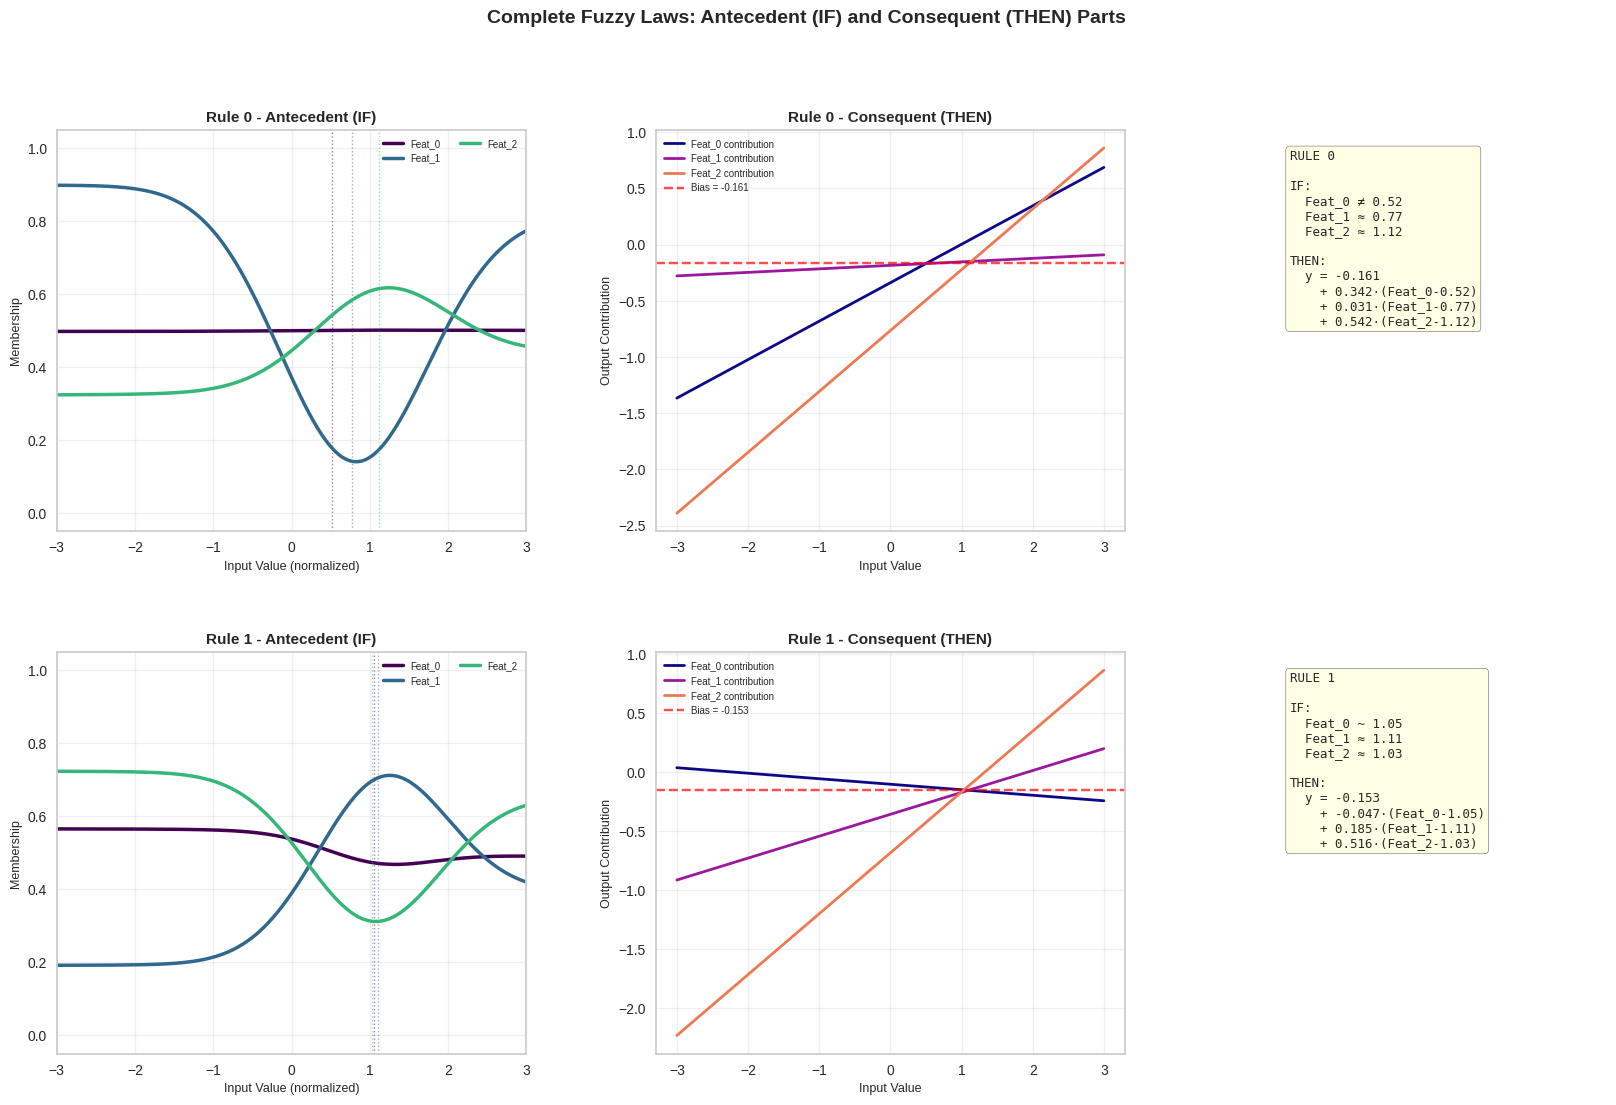

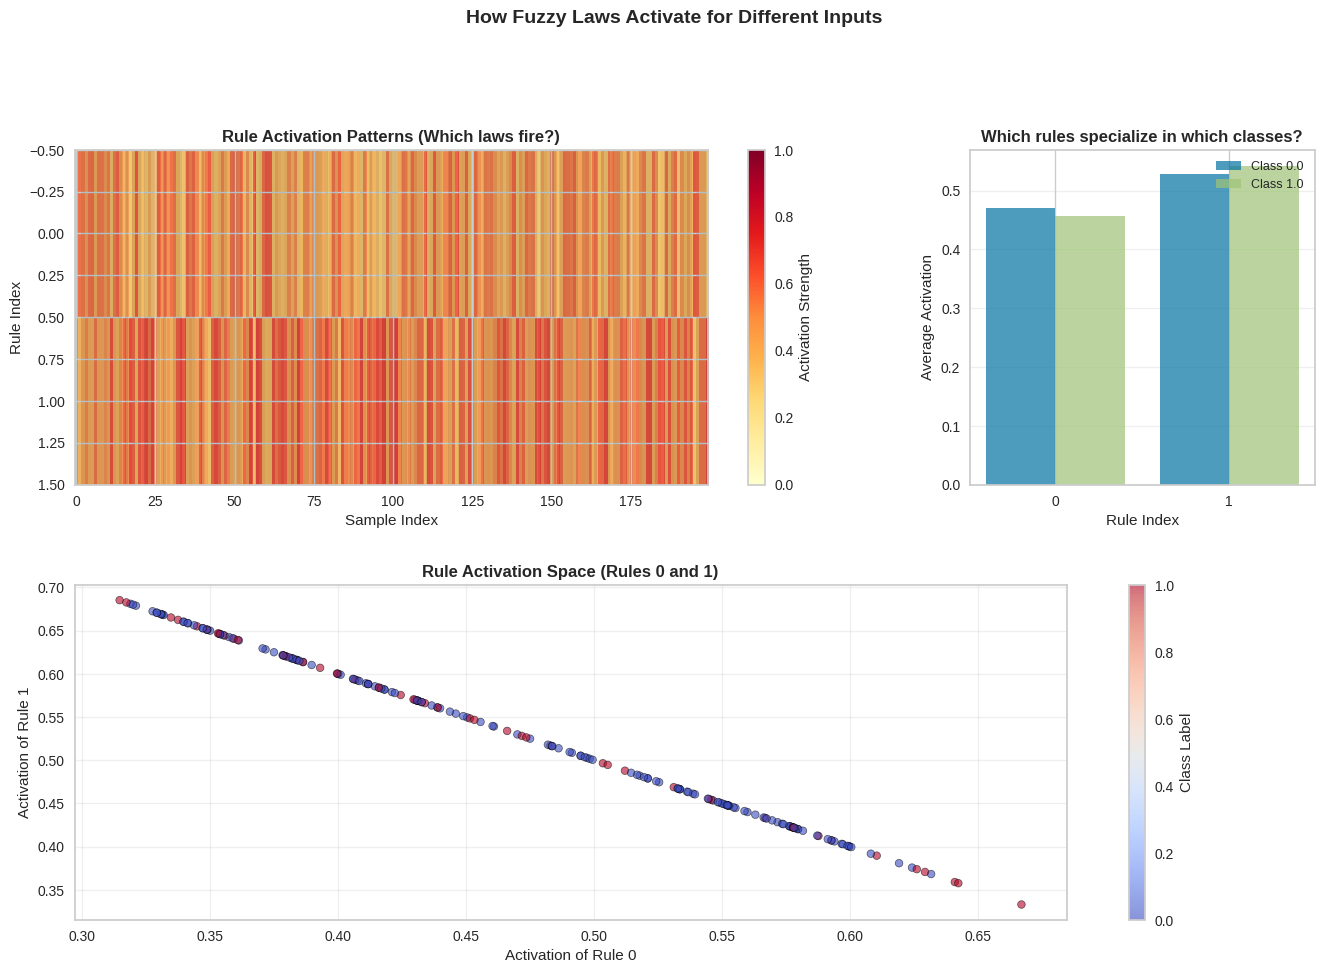

In [10]:
# plot the complete fuzzy laws (both antecedent and consequent)
from utils.law_visualization import (
    plot_fuzzy_laws_complete,
    plot_law_activation_map,
    visualize_complete_law_structure,
    print_fuzzy_rules_structured
)

# ============================================================================
# VISUALIZE COMPLETE FUZZY LAWS (ANTECEDENT + CONSEQUENT)
# ============================================================================

if model_type in ["gift", "gift-mamdani", "giftshift", "giftshiftentropy"]:
    X_train_np, y_train_np = experiment.train_numpy()

    # Build feature names for the input dimension.
    feature_names = [f'Feat_{i}' for i in range(X_train_np.shape[1])]

    # Build class names from the actual experiment labels.
    class_names = [str(c) for c in np.unique(y_train_np)]

    visualize_complete_law_structure(
        model=model,
        dataloader=train_loader,  # For activation analysis
        feature_names=feature_names,
        class_names=class_names,
        rule_indices=[0, 1, 2, 3],  # Show first 4 rules (adjust as needed)
        save_dir='./law_visualizations'  # Saves figures to disk
    )

elif model_type == 'litanfis':
    X_train_np, y_train_np = experiment.train_numpy()
    plot_litanfis_mfs(model, feature_names=None)


In [11]:
'''from model.visual import visualize_full_fuzzy_system

visualize_full_fuzzy_system(
    model,
    image_shape=(8, 8)
)'''

'from model.visual import visualize_full_fuzzy_system\n\nvisualize_full_fuzzy_system(\n    model,\n    image_shape=(8, 8)\n)'

In [12]:
with open(f'results/{model_type}_{experiment.__class__.__name__}_{model_params["rules"]}.txt', mode='w') as f:
    f.write(result)

In [13]:
'''
# plot the membership functions
from utils.mf_plot import plot_litanfis_mfs, plot_gift_mfs, plot_gift_param_progress
if model_type == "gift" or model_type == "gift-mamdani" or model_type == "giftshift" or model_type == "giftshiftentropy":
    X_train_np, y_train_np = experiment.train_numpy() 
    plot_gift_mfs(model, feature_names=None)


if model_type == 'litanfis':
    X_train_np, y_train_np = experiment.train_numpy()
    plot_litanfis_mfs(model, feature_names=None)

'''


'\n# plot the membership functions\nfrom utils.mf_plot import plot_litanfis_mfs, plot_gift_mfs, plot_gift_param_progress\nif model_type == "gift" or model_type == "gift-mamdani" or model_type == "giftshift" or model_type == "giftshiftentropy":\n    X_train_np, y_train_np = experiment.train_numpy() \n    plot_gift_mfs(model, feature_names=None)\n\n\nif model_type == \'litanfis\':\n    X_train_np, y_train_np = experiment.train_numpy()\n    plot_litanfis_mfs(model, feature_names=None)\n\n'

In [14]:
# ROC Curve (Binary or One‑vs‑Rest) with Zoom-in on High Performance
'''import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

X_test, y_test = experiment.test_numpy()
y_score = sk_model.predict_proba(X_test)

classes = np.unique(y_test)
n_classes = len(classes)

plt.figure(figsize=(8, 8), dpi=200)

# Binary classification
if n_classes == 2:
    # Determine which column(s) to use
    if y_score.shape[1] == 2:
        # Standard case: two columns, second is probability of positive class
        y_score_bin = y_score[:, 1]
    elif y_score.shape[1] == 1:
        # Single column: assume it's probability of the positive class
        y_score_bin = y_score[:, 0]
    else:
        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")

    fpr, tpr, _ = roc_curve(y_test, y_score_bin)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                    estimator_name='Binary classifier').plot()

# Multiclass classification
else:
    # Binarize labels (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=classes)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

    plt.legend(loc="lower right")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")

# Zoom
plt.xlim([0.0, 0.025])
plt.ylim([0.99, 1.0])
plt.grid(True)

plt.show()'''


'import numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import roc_curve, auc, RocCurveDisplay\nfrom sklearn.preprocessing import label_binarize\n\nX_test, y_test = experiment.test_numpy()\ny_score = sk_model.predict_proba(X_test)\n\nclasses = np.unique(y_test)\nn_classes = len(classes)\n\nplt.figure(figsize=(8, 8), dpi=200)\n\n# Binary classification\nif n_classes == 2:\n    # Determine which column(s) to use\n    if y_score.shape[1] == 2:\n        # Standard case: two columns, second is probability of positive class\n        y_score_bin = y_score[:, 1]\n    elif y_score.shape[1] == 1:\n        # Single column: assume it\'s probability of the positive class\n        y_score_bin = y_score[:, 0]\n    else:\n        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")\n\n    fpr, tpr, _ = roc_curve(y_test, y_score_bin)\n    roc_auc = auc(fpr, tpr)\n\n    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,\n                    estimator_name=\'Binary classifier

In [ ]:
# Import necessary modules
import torch
import numpy as np
from tests.evaluate import Evaluator  # or wherever your Evaluator is located

# Configure device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Define model configurations
model_configs = {
    'GIFT': {
        'model_class': GIFT,
        'wrapper_class': SklearnGIFTWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }
} 

'''
'Litanfis': {
        'model_class': LitAnfis,
        'wrapper_class': SklearnLitAnfisWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }, 

'GIFTSHIFTENTROPY': {
        'model_class': GIFTSHIFTENTROPY,
        'wrapper_class': SklearnGIFTSHIFTENTROPYWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
            'entropy_coef': 0.0005
        }
    }


'GIFTSHIFT': {
        'model_class': GIFTSHIFT,
        'wrapper_class': SklearnGIFTSHIFTWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }

'GIFT': {
        'model_class': GIFT,
        'wrapper_class': SklearnGIFTWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }, 
    
'Anfis': {
        'model_class': ANFIS,
        'wrapper_class': SklearnAnfisWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    },

'Unfis': {
        'model_class': UNFIS,
        'wrapper_class': SklearnAnfisWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    },

'Griffin': {
        'model_class': GRIFFIN,
        'wrapper_class': SklearnGRIFFINrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }

'''


# Define learning parameters
learning_params = {
    'batch_size': 32,
    'lr': 0.005,
    'max_lr': 0.01,
    'epochs': 100,
    'alpha': 1.0,
    'min_alpha': 0.0
}

# Create evaluator instance
evaluator = Evaluator(
    experiment=experiment,
    model_configs=model_configs,
    learning_params=learning_params,
    device=device,
    binary=binary,
    noise_levels=[0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    n_runs=30,
    random_state=None,  # Set to None for random results each run i used to set 42
    use_noise=False,   # Set to False for clean data only
    noise_type="gaussian"  # or "salt_pepper"
)

# Run evaluation
results_df = evaluator.evaluate(verbose=True)

# Print detailed report
evaluator.print_detailed_report()

# Plot results (only if noise is enabled)
if evaluator.use_noise:
    evaluator.plot_robustness_curves(save_path="robustness_curves.png")
    evaluator.plot_relative_performance(save_path="relative_performance.png")


🔇 NOISE IS DISABLED - Clean data evaluation only


Noise levels:   0%|          | 0/1 [00:00<?, ?it/s]


Testing: CLEAN DATA (σ = 0)

Training GIFTSHIFTER...
  Run 1/30... Acc=0.7609, LingRich=0.6365, RelaxRate=0.7823
  Run 2/30... Acc=0.7391, LingRich=0.3183, RelaxRate=0.8306
  Run 3/30... Acc=0.7500, LingRich=0.6365, RelaxRate=0.7383
  Run 4/30... Acc=0.7391, LingRich=0.8676, RelaxRate=0.7574
  Run 5/30... Acc=0.7500, LingRich=0.6365, RelaxRate=0.7831
  Run 6/30... Acc=0.7391, LingRich=0.3183, RelaxRate=0.7800
  Run 7/30... Acc=0.7391, LingRich=0.8676, RelaxRate=0.7443
  Run 8/30... Acc=0.7391, LingRich=0.3183, RelaxRate=0.7683
  Run 9/30... Acc=0.7391, LingRich=0.6365, RelaxRate=0.7512
  Run 10/30... Acc=0.7500, LingRich=0.8676, RelaxRate=0.7692
  Run 11/30... Acc=0.7609, LingRich=0.8676, RelaxRate=0.7420
  Run 12/30... Acc=0.7609, LingRich=0.3183, RelaxRate=0.7696
  Run 13/30... Acc=0.7391, LingRich=0.6365, RelaxRate=0.7759
  Run 14/30... Acc=0.7391, LingRich=0.6365, RelaxRate=0.7518
  Run 15/30... Acc=0.7717, LingRich=0.6365, RelaxRate=0.7749
  Run 16/30... Acc=0.7391, LingRich=0.86